# 06 — Do the Cleveland findings hold at the other three sites?

**Phase 3, Step 4: the robustness check.** Everything so far comes from 303
Cleveland patients. A pattern found in one sample can be a quirk of that
sample: its referral habits, its measurement practices, or plain chance. The
strongest check is **replication**: fit the same model to *different
patients* and see whether the same associations appear.

The other three sites (Hungary, Switzerland, Long Beach VA) are that
independent test. Their patients never touched the Cleveland analysis.

**The model.** Only 7 predictors are recorded at every site (notebook 02):
age, sex, chest pain type, resting blood pressure, max heart rate, exercise
angina and ST depression. So this step uses a **core model** with those 7,
coded and scaled exactly as in notebook 05.

**Four checks:**
1. **Replication.** Fit the core model on Cleveland, then separately on the
   other three sites. Do the odds ratios agree?
2. **A formal test of difference.** Do the associations differ between
   Cleveland and the rest by more than chance?
3. **Transport.** Take the model fitted on Cleveland and use it to predict the
   other sites' patients. Does it still rank them well? Are its predicted
   risks right?
4. **Sensitivity.** Do the results change if the four possible duplicate rows
   are removed?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from clean_data import load_clean  # noqa: E402

df = load_clean()
CORE = ["age", "sex", "chest_pain_type", "resting_bp", "max_heart_rate",
        "exercise_angina", "st_depression"]

def model_frame(d):
    return pd.DataFrame({
        "disease": d["disease"].astype(int),
        "site": d["site"].astype(str),
        "age_10": d["age"].astype(float) / 10,
        "male": (d["sex"] == "male").astype(int),
        "chest_pain": d["chest_pain_type"].astype(str),
        "bp_10": d["resting_bp"].astype(float) / 10,
        "max_hr_10": d["max_heart_rate"].astype(float) / 10,
        "exercise_angina": d["exercise_angina"].astype(int),
        "st_depression": d["st_depression"].astype(float),
        "possible_duplicate": d["possible_duplicate"].astype(bool),
    }, index=d.index)

complete = df.dropna(subset=CORE)
m = model_frame(complete)
counts = m.groupby("site")["disease"].agg(patients="count", with_disease="sum")
counts["without_disease"] = counts["patients"] - counts["with_disease"]
counts["% disease"] = (counts["with_disease"] / counts["patients"] * 100).round(0).astype(int)
counts["dropped (missing data)"] = df["site"].value_counts().reindex(counts.index) - counts["patients"]
counts

,patients,with_disease,without_disease,% disease,dropped (missing data)
site,,,,,
cleveland,303,139,164,46,0
hungarian,293,106,187,36,1
switzerland,117,109,8,93,6
va,140,110,30,79,60


**Two constraints shape this step:**

- **Switzerland has only 8 patients without disease, and VA only 30.** A
  model can't learn what separates the groups from 8 examples, so the three
  non-Cleveland sites are **pooled** into one replication sample (550
  patients). A **site term** in the model absorbs the large differences in
  disease rates between sites (36% to 93%), so the odds ratios compare
  patients *within* the same site.
- **Missing data at VA is not random.** 60 VA patients lack at least one
  core measurement, and they are more often patients *without* disease:

In [2]:
va = df[df["site"] == "va"]
va_missing = va[CORE].isna().any(axis=1)
pd.crosstab(va["disease"], va_missing, normalize="index").round(2).rename(
    columns={False: "complete", True: "missing a core value"}).rename_axis("VA: disease")

col_0,complete,missing a core value
VA: disease,,
False,0.59,0.41
True,0.74,0.26


41% of VA patients without disease are dropped, against 26% of those with
disease. The VA patients left in the analysis are therefore more likely to
have disease than VA patients overall. Because the model includes a site
term, this mainly shifts VA's baseline rate rather than the odds ratios, but
it is a limitation to keep in mind.

## 1. Replication: Cleveland vs the other three sites

In [3]:
PREDICTORS = ("age_10 + male + C(chest_pain, Treatment('asymptomatic')) + bp_10"
              " + max_hr_10 + exercise_angina + st_depression")
SITE = " + C(site, Treatment('cleveland'))"
SITE_OTHERS = " + C(site, Treatment('hungarian'))"   # no Cleveland rows here; the choice of reference site doesn't change predictor ORs
LABELS = {
    "age_10": "Age (per 10 years)",
    "male": "Male (vs female)",
    "C(chest_pain, Treatment('asymptomatic'))[T.typical angina]": "Chest pain: typical angina (vs asymptomatic)",
    "C(chest_pain, Treatment('asymptomatic'))[T.atypical angina]": "Chest pain: atypical angina (vs asymptomatic)",
    "C(chest_pain, Treatment('asymptomatic'))[T.non-anginal pain]": "Chest pain: non-anginal (vs asymptomatic)",
    "bp_10": "Resting BP (per 10 mm Hg)",
    "max_hr_10": "Max heart rate (per 10 bpm)",
    "exercise_angina": "Exercise-induced angina",
    "st_depression": "ST depression (per 1 unit)",
}

cle = m[m["site"] == "cleveland"]
others = m[m["site"] != "cleveland"]
fits = {
    "Cleveland": smf.logit("disease ~ " + PREDICTORS, cle).fit(disp=False),
    "Other three sites": smf.logit("disease ~ " + PREDICTORS + SITE_OTHERS, others).fit(disp=False),
    "All four sites": smf.logit("disease ~ " + PREDICTORS + SITE, m).fit(disp=False),
}
N = {"Cleveland": len(cle), "Other three sites": len(others), "All four sites": len(m)}

def or_table(fit):
    ci = np.exp(fit.conf_int())
    t = pd.DataFrame({"OR": np.exp(fit.params), "CI low": ci[0], "CI high": ci[1], "p": fit.pvalues})
    return t.loc[list(LABELS)].set_axis(list(LABELS.values()))

tables = {name: or_table(fit) for name, fit in fits.items()}
combined = pd.concat(tables, axis=1)
combined.round(4).to_csv(ROOT / "reports" / "four_site_logistic_regression.csv")
fmt = lambda t: t.apply(lambda r: f"{r['OR']:.2f} ({r['CI low']:.2f}–{r['CI high']:.2f})", axis=1)
pd.DataFrame({f"{k} (n={N[k]})": fmt(v) for k, v in tables.items()}).rename_axis("Odds ratio (95% CI)")

,Cleveland (n=303),Other three sites (n=550),All four sites (n=853)
Odds ratio (95% CI),,,
Age (per 10 years),1.33 (0.89–1.99),1.09 (0.77–1.55),1.21 (0.94–1.57)
Male (vs female),5.91 (2.76–12.65),2.92 (1.42–6.01),3.55 (2.16–5.84)
Chest pain: typical angina (vs asymptomatic),0.10 (0.03–0.32),1.35 (0.39–4.72),0.34 (0.15–0.76)
Chest pain: atypical angina (vs asymptomatic),0.22 (0.08–0.58),0.11 (0.05–0.24),0.15 (0.08–0.26)
Chest pain: non-anginal (vs asymptomatic),0.13 (0.06–0.30),0.29 (0.16–0.55),0.22 (0.14–0.36)
Resting BP (per 10 mm Hg),1.21 (1.00–1.46),1.07 (0.92–1.24),1.09 (0.97–1.22)
Max heart rate (per 10 bpm),0.80 (0.67–0.96),0.94 (0.83–1.06),0.90 (0.82–0.99)
Exercise-induced angina,2.20 (1.06–4.58),3.74 (2.04–6.84),2.97 (1.90–4.62)
ST depression (per 1 unit),1.97 (1.40–2.76),1.86 (1.36–2.53),1.89 (1.52–2.34)


In [4]:
print("Site terms in the pooled four-site model (odds vs Cleveland, same predictors):")
site_or = np.exp(fits["All four sites"].params.filter(like="C(site"))
site_or.index = [i.split("[T.")[1].rstrip("]") for i in site_or.index]
site_or.round(2)

Site terms in the pooled four-site model (odds vs Cleveland, same predictors):


hungarian       0.80
switzerland    14.28
va              1.30
dtype: float64

**Does each finding replicate?** A simple rule: a Cleveland association
*replicates* if the other three sites show the same direction **and** their
interval excludes 1. It *agrees but is unclear* if the direction matches but
the interval includes 1. It *conflicts* if the direction flips with an
interval that excludes 1.

In [5]:
def verdict(c, o):
    same_dir = np.sign(np.log(c["OR"])) == np.sign(np.log(o["OR"]))
    o_clear = o["CI low"] > 1 or o["CI high"] < 1
    c_clear = c["CI low"] > 1 or c["CI high"] < 1
    if same_dir and o_clear:
        return "replicates" if c_clear else "clear only outside Cleveland"
    if not same_dir and o_clear:
        return "CONFLICTS"
    return "agrees, unclear" if same_dir else "differs, unclear"

rep = pd.DataFrame({
    "Cleveland OR": tables["Cleveland"]["OR"].round(2),
    "other sites OR": tables["Other three sites"]["OR"].round(2),
    "verdict": [verdict(tables["Cleveland"].loc[i], tables["Other three sites"].loc[i])
                for i in LABELS.values()],
})
rep

,Cleveland OR,other sites OR,verdict
Age (per 10 years),1.33,1.09,"agrees, unclear"
Male (vs female),5.91,2.92,replicates
Chest pain: typical angina (vs asymptomatic),0.10,1.35,"differs, unclear"
Chest pain: atypical angina (vs asymptomatic),0.22,0.11,replicates
Chest pain: non-anginal (vs asymptomatic),0.13,0.29,replicates
Resting BP (per 10 mm Hg),1.21,1.07,"agrees, unclear"
Max heart rate (per 10 bpm),0.80,0.94,"agrees, unclear"
Exercise-induced angina,2.20,3.74,replicates
ST depression (per 1 unit),1.97,1.86,replicates


## 2. Is Cleveland formally different from the rest?

Fit one model on all four sites in which every predictor is allowed a
*different* odds ratio at Cleveland (an **interaction** with a
Cleveland indicator). A likelihood-ratio test then asks whether letting the
odds ratios differ improves the fit by more than chance. A small p-value means
the associations genuinely differ; a large one means one shared set of odds
ratios describes all sites acceptably.

In [6]:
m["is_cleveland"] = (m["site"] == "cleveland").astype(int)
same = smf.logit("disease ~ " + PREDICTORS + SITE, m).fit(disp=False)
different = smf.logit(f"disease ~ ({PREDICTORS}) * is_cleveland" + SITE, m).fit(disp=False)
lr = 2 * (different.llf - same.llf)
dof = int(different.df_model - same.df_model)
print(f"Likelihood-ratio statistic = {lr:.1f} on {dof} degrees of freedom, p = {stats.chi2.sf(lr, dof):.3f}")

inter = different.params.filter(like=":is_cleveland")
inter_p = different.pvalues.filter(like=":is_cleveland")
pd.DataFrame({"ratio of ORs (Cleveland / others)": np.exp(inter).round(2), "p": inter_p.round(3)},
             index=inter.index).set_axis([LABELS[i.split(":")[0]] for i in inter.index])

Likelihood-ratio statistic = 19.7 on 9 degrees of freedom, p = 0.020


,ratio of ORs (Cleveland / others),p
Chest pain: atypical angina (vs asymptomatic),1.94,0.286
Chest pain: non-anginal (vs asymptomatic),0.46,0.135
Chest pain: typical angina (vs asymptomatic),0.07,0.003
Age (per 10 years),1.22,0.462
Male (vs female),2.02,0.189
Resting BP (per 10 mm Hg),1.13,0.312
Max heart rate (per 10 bpm),0.85,0.142
Exercise-induced angina,0.59,0.274
ST depression (per 1 unit),1.06,0.812


The one predictor that clearly differs is typical angina. How many patients
does that comparison rest on?

In [7]:
(m.assign(group=np.where(m["site"] == "cleveland", "Cleveland", "Other three sites"))
  .groupby(["group", "chest_pain"])["disease"].agg(patients="count", pct_disease="mean")
  .assign(pct_disease=lambda t: (t["pct_disease"] * 100).round(0).astype(int)))

patients  pct_disease
group             chest_pain                             
Cleveland         asymptomatic           144           73
                  atypical angina         50           18
                  non-anginal pain        86           21
                  typical angina          23           30
Other three sites asymptomatic           319           81
                  atypical angina        116           12
                  non-anginal pain        97           42
                  typical angina          18           61

## 3. Transport: does a Cleveland model work elsewhere?

A model is only useful if it works on patients it was not built from. Fit the
core model on Cleveland only, then predict each other site's patients. Two
separate questions:

- **Discrimination (AUC):** does the model still *rank* patients correctly,
  with higher risk for those with disease? (Same measure as notebook 05.)
- **Calibration:** are the predicted *risks* right? Compare the average
  predicted risk at a site with the share who actually have disease.

A model can rank well but be badly calibrated, for example if it was built
where disease is less common. AUC intervals come from 2,000 bootstrap
resamples of each site's patients.

In [8]:
def auc(y, score):
    pos, neg = score[y == 1], score[y == 0]
    return stats.mannwhitneyu(pos, neg).statistic / (len(pos) * len(neg))

rng = np.random.default_rng(7)
cle_fit = fits["Cleveland"]
rows = []
for site in ["cleveland", "hungarian", "switzerland", "va"]:
    s = m[m["site"] == site]
    y = s["disease"].to_numpy()
    pred = cle_fit.predict(s).to_numpy()
    boots = []
    for _ in range(2000):
        idx = rng.integers(0, len(s), len(s))
        if 0 < y[idx].sum() < len(idx):
            boots.append(auc(y[idx], pred[idx]))
    rows.append({"site": site, "patients": len(s), "without disease": int((y == 0).sum()),
                 "AUC": auc(y, pred), "AUC 95% CI": "{:.2f}–{:.2f}".format(*np.percentile(boots, [2.5, 97.5])),
                 "observed % disease": y.mean() * 100, "mean predicted %": pred.mean() * 100})
transport = pd.DataFrame(rows).set_index("site")
transport["AUC"] = transport["AUC"].round(3)
transport[["observed % disease", "mean predicted %"]] = transport[["observed % disease", "mean predicted %"]].round(0).astype(int)
transport

,patients,without disease,AUC,AUC 95% CI,observed % disease,mean predicted %
site,,,,,,
cleveland,303,164,0.895,0.86–0.93,46,46
hungarian,293,187,0.872,0.82–0.91,36,43
switzerland,117,8,0.747,0.58–0.90,93,70
va,140,30,0.725,0.62–0.82,79,81


Cleveland's AUC here is measured on the same patients the model was fitted
to, so it is optimistic (notebook 05 showed a gap of about 0.03). The other
three rows are honest out-of-sample tests.

## 4. Sensitivity: the possible duplicates

Four rows are flagged `possible_duplicate` (notebook 02): two identical pairs,
one in Hungary and one at VA. Refit the pooled model without them and see
whether anything moves.

In [9]:
no_dup = m[~m["possible_duplicate"]]
fit_nd = smf.logit("disease ~ " + PREDICTORS + SITE, no_dup).fit(disp=False)
nd = or_table(fit_nd)
change = (nd["OR"] / tables["All four sites"]["OR"] - 1) * 100
print(f"Rows removed: {len(m) - len(no_dup)}")
print(f"Largest change in any odds ratio: {change.abs().max():.1f}%")

Rows removed: 4
Largest change in any odds ratio: 3.6%


## 5. The comparison in one picture

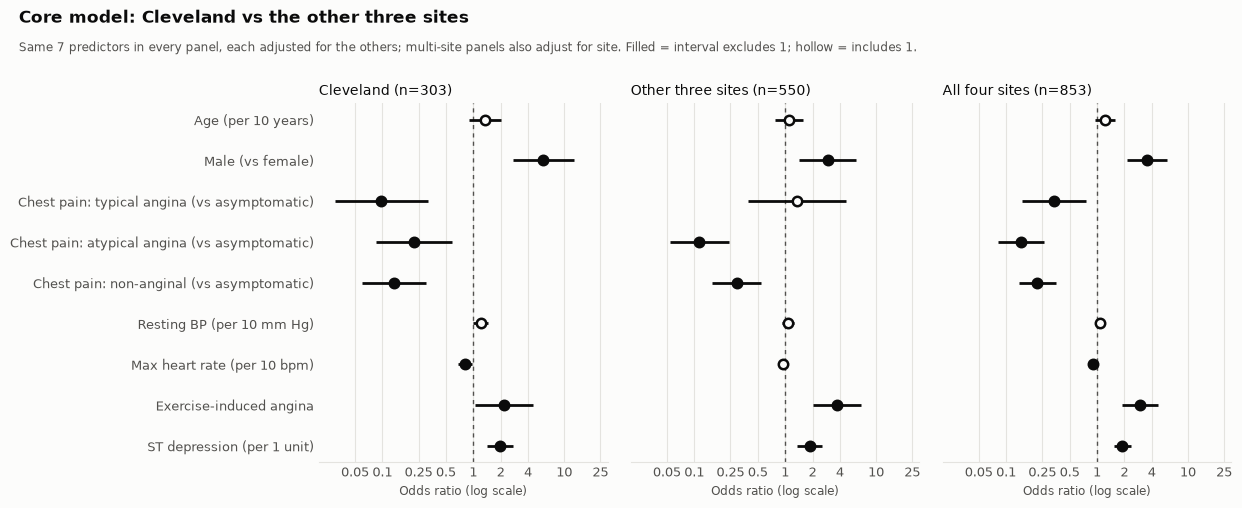

In [10]:
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
                     "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9})
rows_ = list(LABELS.values())[::-1]
y = np.arange(len(rows_))
fig, axes = plt.subplots(1, 3, figsize=(12.5, 5.2), sharey=True, gridspec_kw={"wspace": 0.08})
for ax, name in zip(axes, tables):
    t = tables[name].reindex(rows_)
    ax.axvline(1, color=INK_2, linewidth=1, linestyle=(0, (3, 3)), zorder=1)
    for yi, (_, r) in zip(y, t.iterrows()):
        clear = r["CI low"] > 1 or r["CI high"] < 1
        ax.hlines(yi, r["CI low"], r["CI high"], color=INK, linewidth=2, zorder=2)
        ax.scatter(r["OR"], yi, s=46, zorder=3, linewidths=1.8, edgecolors=INK,
                   facecolors=INK if clear else SURFACE)
    ax.set_xscale("log")
    ax.set_xlim(0.02, 30)
    ax.set_xticks([0.05, 0.1, 0.25, 0.5, 1, 2, 4, 10, 25],
                  ["0.05", "0.1", "0.25", "0.5", "1", "2", "4", "10", "25"])
    ax.minorticks_off()
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.set_title(f"{name} (n={N[name]})", loc="left", fontsize=10, color=INK)
    ax.set_xlabel("Odds ratio (log scale)", color=INK_2, fontsize=8.5)
axes[0].set_yticks(y, rows_)
fig.suptitle("Core model: Cleveland vs the other three sites", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.text(0.01, 0.9, "Same 7 predictors in every panel, each adjusted for the others; multi-site "
         "panels also adjust for site. Filled = interval excludes 1; hollow = includes 1.",
         fontsize=8.5, color=INK_2)
fig.subplots_adjust(left=0.25, right=0.98, top=0.8, bottom=0.11)
fig.savefig(ROOT / "reports" / "figures" / "four_site_odds_ratios.png", dpi=200)
plt.show()

## 6. What the check shows

### Most Cleveland findings replicate in independent patients

In 550 patients the Cleveland analysis never saw:

| Finding | Cleveland OR | Other three sites OR | |
|---|---|---|---|
| **ST depression** (per unit) | 1.97 | 1.86 | nearly identical |
| **Exercise-induced angina** | 2.20 | 3.74 | same direction, stronger outside |
| **Male sex** | 5.91 | 2.92 | same direction, weaker outside |
| **Atypical / non-anginal chest pain vs asymptomatic** | 0.22 / 0.13 | 0.11 / 0.29 | same direction, lower odds than asymptomatic everywhere |

These are the study's most trustworthy results. Removing the four possible
duplicate rows changes no odds ratio by more than 3.6%.

### One finding does not replicate: typical angina

At Cleveland, patients with typical angina had far *lower* odds than
asymptomatic patients (OR 0.10). At the other sites the estimate is 1.35,
with an interval from 0.39 to 4.72. The interaction test for this term gives
p = 0.003, and it is the main reason the overall test of "is Cleveland
different?" comes out at p = 0.02.

The difference rests on very few patients: 23 with typical angina at
Cleveland and 18 across the other three sites. 61% of those 18 have
disease, compared with 30% at Cleveland. The data can't say whether this
reflects different referral practices, different ways of classifying
chest pain, or chance in small groups. What it does say is that **the
"asymptomatic is highest-risk" pattern holds against atypical and
non-anginal pain everywhere, but not reliably against typical angina.**

### Weaker outside Cleveland

- **Max heart rate:** clear at Cleveland (0.80 per 10 bpm), unclear elsewhere
  (0.94, 0.83–1.06). The direction agrees and the formal test doesn't show a
  difference (p = 0.14), so this is "weaker", not "contradicted". Note that
  VA dropped 26% of its patients for missing values, heart rate among them.
- **Age and resting blood pressure** stay unclear everywhere, consistent
  with notebook 05.

### Sites differ enormously in their baseline

Holding all 7 predictors equal, a Swiss patient has about **14 times the
odds** of disease of a Cleveland patient. The predictors don't explain why
93% of Swiss patients had disease; that is about who was referred and
recorded there, not about their measurements. This is exactly why the
pooled model includes a site term.

### A Cleveland model transported to other sites

| Site | AUC (95% CI) | Observed % disease | Predicted % |
|---|---|---|---|
| Hungary | 0.87 (0.82–0.91) | 36 | 43 |
| Switzerland | 0.75 (0.58–0.90) | 93 | 70 |
| VA | 0.73 (0.62–0.82) | 79 | 81 |

- **Hungary: ranking transfers well.** AUC 0.87 matches Cleveland's own
  cross-validated 0.87 (notebook 05, Model A). Predicted risk is a little
  too high (43% vs 36%).
- **Switzerland and VA: ranking is noticeably weaker.** Both samples are
  almost all patients with disease (8 and 30 without), so there are few
  comparisons to rank and the intervals are wide. Switzerland's risk is
  badly under-predicted (70% vs 93%): a model inherits the baseline of the
  place it was built.

**The lesson: good discrimination and good calibration are different
properties.** A model can rank patients well and still give the wrong
absolute risks when moved to a population with a different disease rate.

## Phase 3 conclusion

Across two model types, two samples and one out-of-sample test, the
consistent picture is:

1. **Robust:** ST depression, exercise-induced angina and male sex are
   associated with higher odds of disease; atypical and non-anginal chest
   pain with lower odds than no chest pain. These hold at Cleveland and in
   the independent sites.
2. **Cleveland-specific or uncertain:** typical angina's low odds, and the
   max heart rate association.
3. **Not supported once adjusted:** age, resting blood pressure, cholesterol,
   fasting blood sugar and resting ECG.
4. **Imaging adds** real but modest discrimination (Cleveland only, where it
   exists).

All of this describes **patients referred for angiography, collected before
the dataset was donated in 1988**, not the general population, and all of it is association,
not cause.